# Model Evaluation and Comparison

## Objective
This notebook compares the final LightGBM, Logistic Regression, and Random Forest credit-default models on the same shared held-out test set to provide a fair final performance comparison.

## 1) Imports and Setup

In [1]:
import pickle
import warnings

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
 )

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

## 2) Load Held-Out Test Data

In [2]:
DATA_PATH = 'data/credit_data_test.csv'
TARGET = 'default payment next month'

test_df = pd.read_csv(DATA_PATH)

if TARGET not in test_df.columns:
    raise ValueError(f"Target column '{TARGET}' not found in held-out test file.")
if 'ID' in test_df.columns:
    test_df = test_df.drop(columns=['ID'])

y_test = test_df[TARGET].copy()
print(f'Held-out test shape: {test_df.shape}')

Held-out test shape: (5993, 33)


## 3) Recreate Shared Feature Engineering

In [3]:
def apply_shared_feature_engineering(df):
    df = df.copy()

    for i in range(1, 6):
        df[f'BILL_DIFF_{i}'] = df[f'BILL_AMT{i}'] - df[f'BILL_AMT{i+1}']

    bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
    pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

    df['MEAN_BILL'] = df[bill_cols].mean(axis=1)
    df['MAX_PAY_STATUS'] = df[pay_status_cols].max(axis=1)
    df['SUM_PAY_AMT'] = df[pay_amt_cols].sum(axis=1)
    df['PAY_RATIO_1'] = df['PAY_AMT1'] / (df['BILL_AMT2'].abs() + 1)

    return df

test_fe = apply_shared_feature_engineering(test_df)
X_test_base = test_fe.drop(columns=[TARGET]).copy()
print(f'Engineered test matrix shape: {X_test_base.shape}')

Engineered test matrix shape: (5993, 32)


## 4) Load Saved Models and Feature Columns

In [4]:
# Artifact paths (exact filenames requested)
LGBM_MODEL_PATH = 'Models/lgbm_model.txt'
LGBM_FEATURE_PATH = 'Models/lgbm_feature_columns.pkl'

LR_MODEL_PATH = 'Models/logreg_model.joblib'
LR_PIPELINE_PATH = 'Models/logreg_pipeline.joblib'
LR_FEATURE_PATH = 'Models/logreg_feature_columns.pkl'

RF_MODEL_PATH = 'Models/rf_model.joblib'
RF_FEATURE_PATH = 'Models/rf_feature_columns.pkl'

# Load artifacts
model_lgbm = lgb.Booster(model_file=LGBM_MODEL_PATH)
lgbm_features = joblib.load(LGBM_FEATURE_PATH)

model_lr = joblib.load(LR_MODEL_PATH)
pipeline_lr = joblib.load(LR_PIPELINE_PATH)
logreg_features = joblib.load(LR_FEATURE_PATH)

model_rf = joblib.load(RF_MODEL_PATH)
rf_features = joblib.load(RF_FEATURE_PATH)

print('Artifacts loaded successfully.')

Artifacts loaded successfully.


## 5) Generate Predictions for Each Model

In [5]:
# --- LightGBM ---
X_test_lgbm = X_test_base.reindex(columns=lgbm_features, fill_value=0)
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
for col in cat_cols:
    if col in X_test_lgbm.columns:
        X_test_lgbm[col] = X_test_lgbm[col].astype('category')

y_prob_lgbm = model_lgbm.predict(X_test_lgbm)
y_pred_lgbm = (y_prob_lgbm >= 0.5).astype(int)

# --- Logistic Regression ---
X_test_lr = X_test_base.copy()
X_test_lr = pd.get_dummies(X_test_lr, columns=[c for c in cat_cols if c in X_test_lr.columns], drop_first=True)
X_test_lr = X_test_lr.reindex(columns=logreg_features, fill_value=0)

# Prefer saved final logistic model; fallback to pipeline if needed
try:
    y_prob_lr = model_lr.predict_proba(X_test_lr)[:, 1]
except Exception:
    y_prob_lr = pipeline_lr.predict_proba(X_test_lr)[:, 1]
y_pred_lr = (y_prob_lr >= 0.5).astype(int)

# --- Random Forest ---
X_test_rf = X_test_base.reindex(columns=rf_features, fill_value=0)
y_prob_rf = model_rf.predict_proba(X_test_rf)[:, 1]
y_pred_rf = (y_prob_rf >= 0.5).astype(int)

print('Predictions generated for all models.')

Predictions generated for all models.


## 6) Compute Comparison Metrics

In [6]:
def model_metrics(name, y_true, y_prob, y_pred):
    return {
        'Model': name,
        'Test AUC': roc_auc_score(y_true, y_prob),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
    }

metrics_rows = [
    model_metrics('LightGBM', y_test, y_prob_lgbm, y_pred_lgbm),
    model_metrics('Logistic Regression', y_test, y_prob_lr, y_pred_lr),
    model_metrics('Random Forest', y_test, y_prob_rf, y_pred_rf),
]

## 7) Comparison Table

In [7]:
results_df = pd.DataFrame(metrics_rows).sort_values('Test AUC', ascending=False).reset_index(drop=True)
display(results_df.round(4))

cm_summary = pd.DataFrame([
    {'Model': 'LightGBM', 'TN': confusion_matrix(y_test, y_pred_lgbm)[0, 0], 'FP': confusion_matrix(y_test, y_pred_lgbm)[0, 1], 'FN': confusion_matrix(y_test, y_pred_lgbm)[1, 0], 'TP': confusion_matrix(y_test, y_pred_lgbm)[1, 1]},
    {'Model': 'Logistic Regression', 'TN': confusion_matrix(y_test, y_pred_lr)[0, 0], 'FP': confusion_matrix(y_test, y_pred_lr)[0, 1], 'FN': confusion_matrix(y_test, y_pred_lr)[1, 0], 'TP': confusion_matrix(y_test, y_pred_lr)[1, 1]},
    {'Model': 'Random Forest', 'TN': confusion_matrix(y_test, y_pred_rf)[0, 0], 'FP': confusion_matrix(y_test, y_pred_rf)[0, 1], 'FN': confusion_matrix(y_test, y_pred_rf)[1, 0], 'TP': confusion_matrix(y_test, y_pred_rf)[1, 1]},
])
display(cm_summary)

,Model,Test AUC,Accuracy,Precision,Recall,F1
0,LightGBM,0.7761,0.8200,0.6798,0.3522,0.4640
1,Random Forest,0.7701,0.7888,0.5215,0.5498,0.5352
2,Logistic Regression,0.7364,0.8109,0.6217,0.3718,0.4653


,Model,TN,FP,FN,TP
0,LightGBM,4447,220,859,467
1,Logistic Regression,4367,300,833,493
2,Random Forest,3998,669,597,729


Although accuracy, precision, recall, and F1-score provide useful threshold-based perspectives, the primary model-selection metric in this project is test AUC. This is because the dataset is imbalanced and AUC better reflects each model’s overall ability to distinguish defaulters from non-defaulters across possible decision thresholds. The threshold-based metrics are therefore used as supporting measures to interpret practical classification behavior at the default 0.5 cutoff.

## 8) ROC Curve Comparison

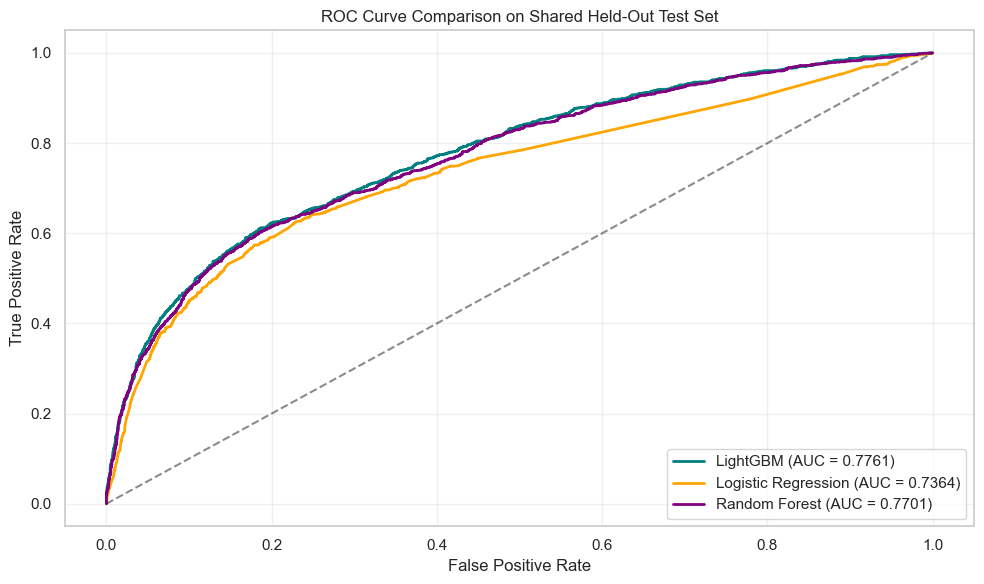

In [8]:
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(10, 6))
plt.plot(fpr_lgbm, tpr_lgbm, lw=2, color='teal', label=f"LightGBM (AUC = {roc_auc_score(y_test, y_prob_lgbm):.4f})")
plt.plot(fpr_lr, tpr_lr, lw=2, color='orange', label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.4f})")
plt.plot(fpr_rf, tpr_rf, lw=2, color='purple', label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.4f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison on Shared Held-Out Test Set')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9) Results

In [9]:
best_model = results_df.iloc[0]['Model']
best_auc = results_df.iloc[0]['Test AUC']
worst_auc = results_df.iloc[-1]['Test AUC']
auc_gap = best_auc - worst_auc

print(f'Best model by held-out Test AUC: {best_model} ({best_auc:.4f})')
if auc_gap >= 0.02:
    print(f'The AUC gap between best and lowest model is noticeable ({auc_gap:.4f}).')
else:
    print(f'The AUC gap between best and lowest model is modest ({auc_gap:.4f}).')

print('AUC is the primary comparison metric here because default prediction is class-imbalanced and ranking quality is central.')
print('Threshold-based metrics (accuracy, precision, recall, F1) provide additional operating-point context at threshold 0.5.')

Best model by held-out Test AUC: LightGBM (0.7761)
The AUC gap between best and lowest model is noticeable (0.0398).
AUC is the primary comparison metric here because default prediction is class-imbalanced and ranking quality is central.
Threshold-based metrics (accuracy, precision, recall, F1) provide additional operating-point context at threshold 0.5.


## 10) Final Conclusion
The shared held-out test comparison identifies the best-performing final model by AUC while keeping evaluation consistent across model families. LightGBM represents the boosting-based benchmark, Random Forest represents the bagging-based tree benchmark, and Logistic Regression remains the interpretable linear benchmark.

LightGBM was selected as the final model because it achieved the strongest held-out test AUC (0.7761), indicating the best overall ability to rank higher-risk clients above lower-risk clients. Random Forest performed competitively (0.7701) and showed stronger recall at the default 0.5 threshold, while Logistic Regression (0.7364) served as a useful interpretable linear benchmark. Overall, LightGBM provided the best balance of predictive performance and generalization, so it was retained as the final model for the project.